
---
date: "2026-09-12"
date-modified: last-modified
format:
  html:
    toc: true
---


# Euler's Method for ODEs

Most nonlinear [ordinary differential equations](ode-intro.ipynb) cannot be solved analytically in terms of elementary functions. Numerical methods approximate the solution $y(x)$ of an [Initial Value Problem]() on a discrete grid by stepping along the local tangents provided by the [Direction Field](ode-direction-fields.ipynb).

## 1\. The Forward Euler Scheme

::: {#def-euler-method}
## Euler's Forward Method
Consider the first-order IVP:
$$
\begin{cases}
y' = f(x, y) \\
y(x_0) = y_0
\end{cases}
$$
on the interval $[x_0, X]$. Let $N \in \mathbb{N}$ and define a uniform step size $h = \frac{X - x_0}{N}$ with discrete grid points $x_n = x_0 + n h$ for $n = 0, 1, \dots, N$. 

**Euler's method** approximates the exact trajectory $y(x_n)$ by discrete values $y_n$ computed via the single-step recurrence:
$$
\begin{aligned}
x_{n+1} &= x_n + h \\
y_{n+1} &= y_n + h f(x_n, y_n), \quad n = 0, 1, \dots, N-1
\end{aligned}
$$
:::

::: {.callout-tip collapse="true"}
## Derivations of Euler's Method
Euler's recurrence can be derived through three equivalent mathematical perspectives:

**1. Tangent Line (First-Order Taylor Polynomial):**
Assuming $y \in C^2[x_0, X]$, the [Taylor expansion]() of $y(x)$ about $x_n$ with step $h$ yields:
$$
y(x_{n+1}) = y(x_n + h) = y(x_n) + h y'(x_n) + \frac{h^2}{2} y''(\xi_n)
$$
for some $\xi_n \in (x_n, x_{n+1})$. Substituting the differential equation $y'(x_n) = f(x_n, y(x_n))$ and dropping the $O(h^2)$ remainder:
$$
y(x_{n+1}) \approx y(x_n) + h f(x_n, y(x_n))
$$
Replacing exact values $y(x_n)$ with approximations $y_n$ produces Euler's scheme.

**2. Forward Finite Difference Quotient:**
Approximating the derivative $y'(x_n)$ by the forward difference quotient:
$$
y'(x_n) \approx \frac{y(x_{n+1}) - y(x_n)}{h}
$$
Equating this to $f(x_n, y(x_n))$ and isolating $y(x_{n+1})$ gives:
$$
y(x_{n+1}) \approx y(x_n) + h f(x_n, y(x_n))
$$

**3. Numerical Quadrature (Left Riemann Sum):**
Integrating $y'(t) = f(t, y(t))$ over $[x_n, x_{n+1}]$:
$$
y(x_{n+1}) - y(x_n) = \int_{x_n}^{x_{n+1}} f(t, y(t)) \, dt
$$
Approximating the integral via the left-endpoint rectangle rule $\int_{x_n}^{x_{n+1}} g(t) \, dt \approx h g(x_n)$ yields:
$$
y(x_{n+1}) \approx y(x_n) + h f(x_n, y(x_n))
$$
$\blacksquare$
:::

::: {.callout-note}
## Intuition: The Euler Polygon
Geometrically, Euler's method evaluates the slope $f(x_n, y_n)$ from the [Direction Field](ode-direction-fields.ipynb) at the current state $(x_n, y_n)$ and extends a straight line segment of horizontal length $h$ with that fixed slope to reach the next state $(x_{n+1}, y_{n+1})$. The resulting piecewise-linear curve is the **Euler-Cauchy polygon**. In the limit as $h \to 0$, this polygon converges to the true curved trajectory.
:::


## 2\. Error Analysis and Convergence

Numerical accuracy is characterized by two distinct quantities: **local truncation error** (introduced at a single step) and **global error** (accumulated across the entire integration interval).

::: {#def-euler-lte}
## Local Truncation Error (LTE)
The **local truncation error** $\tau_{n+1}$ is the error committed in a single step assuming the previous node value was exact ($y_n = y(x_n)$):
$$
\tau_{n+1} = y(x_{n+1}) - \left[ y(x_n) + h f(x_n, y(x_n)) \right]
$$
By Taylor's Theorem with Lagrange remainder:
$$
y(x_{n+1}) = y(x_n) + h y'(x_n) + \frac{h^2}{2} y''(\xi_n) = y(x_n) + h f(x_n, y(x_n)) + \frac{h^2}{2} y''(\xi_n)
$$
Hence:
$$
\tau_{n+1} = \frac{h^2}{2} y''(\xi_n) = O(h^2)
$$
:::

::: {#thm-euler-convergence}
## Global Error Bound of Euler's Method
Let $f: [x_0, X] \times \mathbb{R} \to \mathbb{R}$ be continuous and satisfy a [Lipschitz condition]() in its second variable with Lipschitz constant $L > 0$:
$$
|f(x, u) - f(x, v)| \le L |u - v| \quad \forall x \in [x_0, X], \; u, v \in \mathbb{R}
$$
Assume the exact solution satisfies $y \in C^2[x_0, X]$, with $|y''(x)| \le M$ for all $x \in [x_0, X]$. Then the global discretization error $e_n = |y(x_n) - y_n|$ satisfies:
$$
e_n \le \frac{M h}{2 L} \left( e^{L(x_n - x_0)} - 1 \right) = O(h) \quad \text{for all } n = 0, 1, \dots, N
$$
Consequently, Euler's method is a **first-order convergent method**: as $h \to 0$, the maximum global error vanishes linearly with $h$.
:::

::: {.callout-tip collapse="true"}
## Proof of Global Error Bound
Subtracting the numerical recurrence from the Taylor expansion:
$$
\begin{aligned}
y(x_{n+1}) &= y(x_n) + h f(x_n, y(x_n)) + \frac{h^2}{2} y''(\xi_n) \\
y_{n+1} &= y_n + h f(x_n, y_n)
\end{aligned}
$$
Subtracting the two equations yields:
$$
y(x_{n+1}) - y_{n+1} = (y(x_n) - y_n) + h \left[ f(x_n, y(x_n)) - f(x_n, y_n) \right] + \frac{h^2}{2} y''(\xi_n)
$$
Applying the triangle inequality and the Lipschitz condition on $f$:
$$
\begin{aligned}
e_{n+1} = |y(x_{n+1}) - y_{n+1}| &\le |y(x_n) - y_n| + h |f(x_n, y(x_n)) - f(x_n, y_n)| + \frac{h^2}{2} |y''(\xi_n)| \\
&\le e_n + h L e_n + \frac{h^2 M}{2} \\
&= (1 + h L) e_n + \frac{h^2 M}{2}
\end{aligned}
$$
Let $\rho = 1 + h L$ and $\delta = \frac{h^2 M}{2}$. Since the initial condition is exact, $e_0 = |y(x_0) - y_0| = 0$. By induction:
$$
\begin{aligned}
e_1 &\le \delta \\
e_2 &\le \rho e_1 + \delta \le (\rho + 1) \delta \\
&\;\;\vdots \\
e_n &\le \delta \sum_{k=0}^{n-1} \rho^k = \delta \frac{\rho^n - 1}{\rho - 1} = \frac{h^2 M}{2} \frac{(1 + h L)^n - 1}{h L} = \frac{h M}{2 L} \left[ (1 + h L)^n - 1 \right]
\end{aligned}
$$
Using the standard inequality $1 + z \le e^z$ for all $z \ge 0$, we have $(1 + h L)^n \le e^{n h L} = e^{L (x_n - x_0)}$. Substituting this bound yields:
$$
e_n \le \frac{M h}{2 L} \left( e^{L(x_n - x_0)} - 1 \right)
$$
Since $\frac{M}{2 L} (e^{L(X - x_0)} - 1)$ is independent of $h$, $e_n = O(h)$. $\blacksquare$
:::

::: {.callout-warning}
## Step-Size Restriction and Numerical Stability
For stiff differential equations such as the scalar test equation $y' = -\lambda y$ with $\lambda > 0$, Euler's iteration yields $y_{n+1} = (1 - h\lambda)y_n$. Numerical stability requires the amplification factor $|1 - h\lambda| \le 1$, imposing the strict step-size constraint:
$$
h \le \frac{2}{\lambda}
$$
If $h > \frac{2}{\lambda}$, the numerical approximation undergoes explosive oscillations, diverging from the true exponentially decaying solution $y(x) = y_0 e^{-\lambda x} \to 0$.
:::

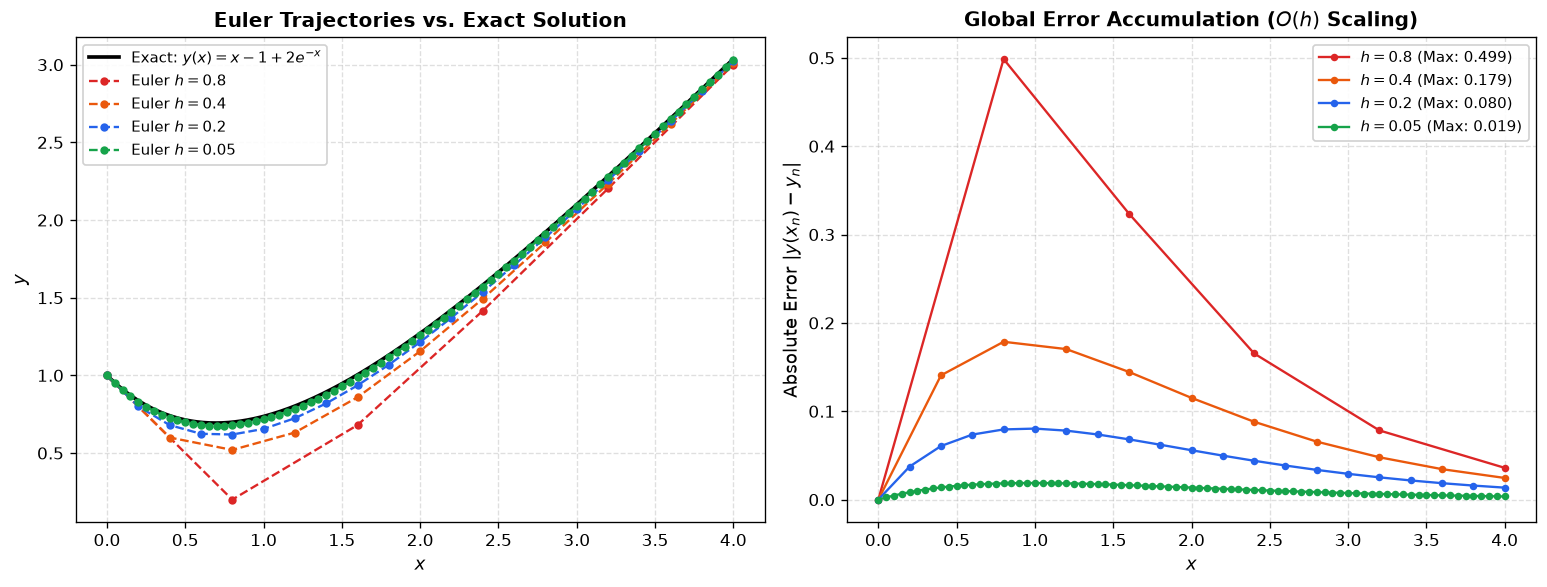

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Solve IVP: y' = x - y, y(0) = 1 on [0, 4]
def f(x, y):
    return x - y

def exact_sol(x):
    return x - 1 + 2 * np.exp(-x)

def euler_solve(f, x0, y0, X, h):
    N = int(np.round((X - x0) / h))
    x = np.linspace(x0, X, N + 1)
    y = np.zeros(N + 1)
    y[0] = y0
    for n in range(N):
        y[n+1] = y[n] + h * f(x[n], y[n])
    return x, y

x0, y0, X = 0.0, 1.0, 4.0
step_sizes = [0.8, 0.4, 0.2, 0.05]
colors = ["#dc2626", "#ea580c", "#2563eb", "#16a34a"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

# Dense exact solution for comparison
x_dense = np.linspace(x0, X, 300)
y_dense = exact_sol(x_dense)

ax1.plot(x_dense, y_dense, "k-", linewidth=2.2, label=r"Exact: $y(x) = x - 1 + 2e^{-x}$")

for h, col in zip(step_sizes, colors):
    x_num, y_num = euler_solve(f, x0, y0, X, h)
    y_true_at_nodes = exact_sol(x_num)
    err = np.abs(y_true_at_nodes - y_num)
    
    # Trajectory plot
    ax1.plot(x_num, y_num, "o--", color=col, linewidth=1.4, markersize=4, label=f"Euler $h = {h}$")
    
    # Error plot
    ax2.plot(x_num, err, "o-", color=col, linewidth=1.4, markersize=3.5, label=f"$h = {h}$ (Max: {np.max(err):.3f})")

ax1.set_xlabel("$x$", fontsize=11)
ax1.set_ylabel("$y$", fontsize=11)
ax1.set_title("Euler Trajectories vs. Exact Solution", fontsize=12, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(fontsize=9, framealpha=0.9)

ax2.set_xlabel("$x$", fontsize=11)
ax2.set_ylabel(r"Absolute Error $|y(x_n) - y_n|$", fontsize=11)
ax2.set_title(r"Global Error Accumulation ($O(h)$ Scaling)", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()